In [2]:
import itertools
import functools
from math import pi

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FormatStrFormatter
import numpy as np
import xarray as xr

from fluxoniumcr import DATA_DIR


plt.style.use("fluxoniumcr.plotting.paper")

In [3]:
from matplotlib.colors import LinearSegmentedColormap

myblues = LinearSegmentedColormap.from_list(
    "myblues",
    [
        "#f7fbff",
        "#deebf7",
        "#c6dbef",
        "#9ecae1",
        "#6baed6",
        "#4292c6",
        "#2171b5",
        "#08519c",
        "#08306b",
    ]
)

myoranges = LinearSegmentedColormap.from_list(
    "myoranges",
    ['#fff5eb','#fee6ce','#fdd0a2','#fdae6b','#fd8d3c','#f16913','#d94801','#a63603','#7f2704'],
)

In [4]:
dataset1 = xr.load_dataset(
    DATA_DIR/"JC_heatmap"/"ELdivEJ_1=0.25,ELdivEJ_2=0.25,control_frequency=0.5,target_frequency=0.8,zz_kHz=50.hdf5",
)


dataset2 = xr.load_dataset(
    DATA_DIR/"JC_heatmap"/"ELdivEJ_1=0.1,ELdivEJ_2=0.25,control_frequency=0.5,target_frequency=0.8,zz_kHz=50.hdf5",
)

dataset3 = xr.load_dataset(
    DATA_DIR/"JC_heatmap"/"ELdivEJ_1=0.25,ELdivEJ_2=0.25,control_frequency=0.6,target_frequency=0.7,zz_kHz=50.hdf5",
)

dataset4 = xr.load_dataset(
    DATA_DIR/"JC_heatmap"/"ELdivEJ_1=0.25,ELdivEJ_2=0.25,control_frequency=0.4,target_frequency=0.9,zz_kHz=50.hdf5",
)
# dataset4 = xr.load_dataset(
#     DATA_DIR/"JC_heatmap"/"ELdivEJ_1=0.25,ELdivEJ_2=0.25,control_frequency=0.3,target_frequency=1.0,zz_kHz=50.hdf5",
# )

In [6]:
def plot_cnot_duration(
        ax,
        cax,
        dataset,
        subfig_label="",
        levels=None,
        contour_labels=False,
):
    cmap = myblues

    zx_data = abs(dataset.JC * dataset.control_qubit_charge_dipole * dataset.target_qubit_charge_dipole).squeeze().data
    cnot_dur_data = pi/2/zx_data
    
    cs = ax.contourf(
        dataset.EJdivEC_2,
        dataset.EJdivEC_1,
        cnot_dur_data,
        levels=levels,
        cmap=cmap,
    )
    cbar = fig.colorbar(cs, cax, label=r"Est. CNOT time [ns]")

    cs2 = ax.contour(
        dataset.EJdivEC_2,
        dataset.EJdivEC_1,
        cnot_dur_data,
        levels=cbar.get_ticks(),
        colors='black',
        linewidths=plt.rcParams['ytick.major.width'],
    )
    ax.clabel(
        cs2,
        fontsize=plt.rcParams['ytick.labelsize'],
        manual=contour_labels,
    )

    ax.set_xlabel(r"$E_{J,\mathrm{t}}/E_{C,\mathrm{t}}$")
    ax.set_ylabel(r"$E_{J,\mathrm{c}}/E_{C,\mathrm{c}}$")
    ax.xaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
    annotation = ax.annotate(
        subfig_label,
        (0.00, 1.00),
        (-26, 4),
        xycoords='axes fraction',
        textcoords='offset points',
        fontweight='medium',
        fontsize=10,
        ha="right",
        va="top",
        zorder=1,
    )

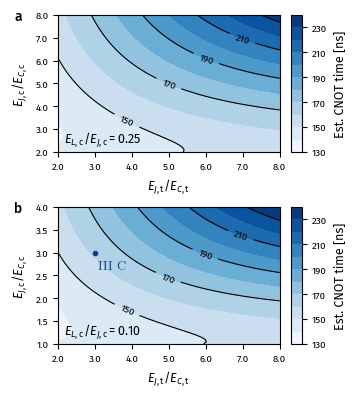

In [8]:
fig = plt.figure(
    figsize=(85/25.4, 95/25.4),
)

gs = GridSpec(
    nrows=2,
    ncols=2,
    figure=fig,
    width_ratios=[100, 5],
    hspace=0.4,
    wspace=0.1,
)

cmap = 'viridis_r'

ax1 = fig.add_subplot(gs[0, 0])
cax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0])
cax2 = fig.add_subplot(gs[1, 1])

plot_cnot_duration(
    ax1,
    cax1,
    dataset1,
    subfig_label="a",
    levels = np.arange(130, 250, 10),
    contour_labels=[
        (4, 4),
        (5, 5),
        (6, 6),
        (7, 7),
    ],
)

plot_cnot_duration(
    ax2,
    cax2,
    dataset2,
    subfig_label="b",
    levels = np.arange(130, 250, 10),
    contour_labels=[
        (4, 2),
        (5, 2.5),
        (6, 3),
        (7, 3.5),
    ],
)

ax2.scatter(3, 3, marker='.', c='C0')
ax2.annotate(
    "III C",
    (3, 3),
    (2, -6),
    textcoords='offset points',
    ha='left',
    va='top',
    c='C0',
    usetex=True,
    fontfamily='Computer Modern',
)

ax1.annotate(
    r"$E_{L,\mathrm{c}}/E_{J,\mathrm{c}}=0.25$",
    (0, 0),
    xytext=(4, 2),
    textcoords='offset points',
    xycoords='axes fraction',
    ha='left',
    va='bottom',
)
ax2.annotate(
    r"$E_{L,\mathrm{c}}/E_{J,\mathrm{c}}=0.10$",
    (0, 0),
    xytext=(4, 2),
    textcoords='offset points',
    xycoords='axes fraction',
    ha='left',
    va='bottom',
)

ax1.set_xlim(2, 8)
ax1.set_ylim(2, 8)
ax2.set_xlim(2, 8)
ax2.set_ylim(1, 4)

fig.subplots_adjust(
    left=0.14,
    right=0.87,
    bottom=0.11,
    top=0.99,
)
fig.savefig("cnot_duration.pdf")

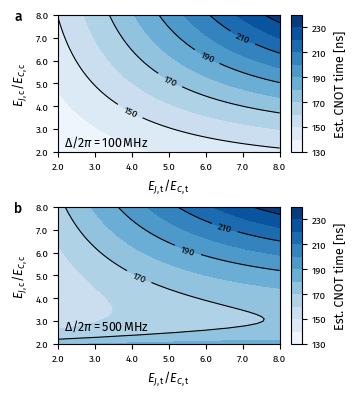

In [9]:
fig = plt.figure(
    figsize=(85/25.4, 95/25.4),
)

gs = GridSpec(
    nrows=2,
    ncols=2,
    figure=fig,
    width_ratios=[100, 5],
    hspace=0.4,
    wspace=0.1,
)

cmap = 'viridis_r'

ax1 = fig.add_subplot(gs[0, 0])
cax1 = fig.add_subplot(gs[0, 1])
ax2 = fig.add_subplot(gs[1, 0])
cax2 = fig.add_subplot(gs[1, 1])

plot_cnot_duration(
    ax1,
    cax1,
    dataset3,
    subfig_label="a",
    levels = np.arange(130, 250, 10),
    contour_labels=[
        (4, 4),
        (5, 5),
        (6, 6),
        (7, 7),
    ],
)

plot_cnot_duration(
    ax2,
    cax2,
    dataset4,
    subfig_label="b",
    levels = np.arange(130, 250, 10),
    contour_labels=[
        (4, 4),
        (5.5, 6),
        (6.5, 7),
    ],
)

ax1.annotate(
    r"$\Delta/2\pi=100\,\mathrm{MHz}$",
    (0, 0),
    xytext=(4, 2),
    textcoords='offset points',
    xycoords='axes fraction',
    ha='left',
    va='bottom',
)
ax2.annotate(
    r"$\Delta/2\pi=500\,\mathrm{MHz}$",
    (0, 0),
    xytext=(4, 8),
    textcoords='offset points',
    xycoords='axes fraction',
    ha='left',
    va='bottom',
)

ax1.set_xlim(2, 8)
ax1.set_ylim(2, 8)
ax2.set_xlim(2, 8)
ax2.set_ylim(2, 8)

fig.subplots_adjust(
    left=0.14,
    right=0.87,
    bottom=0.11,
    top=0.99,
)
fig.savefig("cnot_duration_different_detuning.pdf")